In [57]:
import time
import tracemalloc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [58]:
# Grid settings
GRID_SIZE = 400

X_MIN = -10
X_MAX = 10

Y_MIN = -10
Y_MAX = 10

# Wave settings                 # Parameters: Amplitude and Wavelength λ
AMPLITUDE = 1
WAVELENGTH = 2
FREQUENCY = 1
PHASE_DIFFERENCE = 0

# Animation settings
FRAMES = 300
INTERVAL = 30

# Other settings
TIME = 0
USE_INTENSITY = False

In [59]:
# Wave source class to represent each wave source and calculate its contribution to the wave pattern at any point in space and time
class WaveSource:
    def __init__(self, x, y, amplitude, wavelength, frequency, phase=0):
        self.x = x
        self.y = y
        self.amplitude = amplitude
        self.wavelength = wavelength
        self.frequency = frequency
        self.phase = phase
        
        self.k = 2 * np.pi / wavelength
        self.omega = 2 * np.pi * frequency

    def calculate_distance(self, X, Y):
        r = np.sqrt((X - self.x)**2 + (Y - self.y)**2)
        return r

    def generate_wave(self, X, Y, time):
        r = self.calculate_distance(X, Y)
        
        # Avoid divide by zero
        r = np.where(r < 0.1, 0.1, r)
        
        # Calculate wave using the formula: A * sin(k*r - omega*t + phase) / sqrt(r)
        # The division by sqrt(r) simulates the decrease in amplitude with distance (spherical spreading)
        wave = self.amplitude * np.sin(self.k * r - self.omega * time + self.phase) / np.sqrt(r)
        return wave

In [60]:
# Function to plot the wave pattern
def plot_wave(wave, title="Wave"):
    plt.figure(figsize=(8,6))
    plt.imshow(wave, extent=(X_MIN, X_MAX, Y_MIN, Y_MAX), origin='lower', cmap='viridis')
    
    plt.colorbar(label='Amplitude')
    
    plt.title(title)
    
    plt.xlabel('X')
    plt.ylabel('Y')
    
    plt.tight_layout()
    plt.show()


# Intensity is the square of the wave amplitude
def plot_intensity(wave):
    intensity = wave**2
    plt.figure(figsize=(8,6))

    plt.imshow(intensity, extent=(X_MIN, X_MAX, Y_MIN, Y_MAX), origin="lower", cmap="inferno")

    plt.colorbar(label="Intensity")
    plt.title("Wave Intensity Pattern")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.tight_layout()
    plt.show()

In [61]:
# Animation function
def animate_interference(source1, source2, X, Y):
    fig, ax = plt.subplots(figsize=(8,6))
    image = ax.imshow(np.zeros((GRID_SIZE, GRID_SIZE)), extent=(X_MIN, X_MAX, Y_MIN, Y_MAX), origin='lower', cmap='viridis', animated=True)
    fig.colorbar(image, ax=ax, label="Amplitude")
    
    # Plot the sources
    ax.scatter([source1.x, source2.x], [source1.y, source2.y], color="red", s=100)

    time_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, color="white")
    
    ax.set_title("Wave Interference Animation")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    
    
    # Update function for animation
    def update(frame):
        time = frame * 0.05

        wave1 = source1.generate_wave(X, Y, time)
        wave2 = source2.generate_wave(X, Y, time)

        total_wave = wave1 + wave2
        
        if USE_INTENSITY:
            total_wave = total_wave**2

        image.set_array(total_wave)
        image.set_clim(vmin=np.min(total_wave), vmax=np.max(total_wave))
        time_text.set_text(f"Time: {time:.2f}s")

        return [image], time_text

    animation = FuncAnimation(fig, update, frames=FRAMES, interval=INTERVAL, blit=False)
    return animation

In [62]:
# Utility functions for performance measurement and wave analysis
def measure_runtime(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    end = time.perf_counter()

    runtime = end - start
    print(f"Runtime: {runtime:.6f} seconds")

    return result

# Memory tracking functions using tracemalloc to measure memory usage during wave generation and animation
def start_memory_tracking():
    tracemalloc.start()

# Stop memory tracking and print results
def stop_memory_tracking():
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    print(f"Current Memory: {current/1024**2:.2f} MB")
    print(f"Peak Memory: {peak/1024**2:.2f} MB")



# Functions to calculate energy, RMS, max amplitude, and other statistics of the wave pattern for analysis
def calculate_energy(wave):
    return np.sum(wave**2)

def calculate_rms(wave):
    return np.sqrt(np.mean(wave**2))

def calculate_max_amplitude(wave):
    return np.max(np.abs(wave))

def calculate_statistics(wave):
    return {
        "max": np.max(wave),
        "min": np.min(wave),
        "mean": np.mean(wave),
        "std": np.std(wave)
    }

# Function to calculate percentage difference between two values for comparing different wave patterns or configurations
def percent_difference(a, b):
    return abs(a - b) / (abs(a) + 1e-9) * 100

# Function to print all calculated metrics for a given wave pattern for analysis and comparison
def print_metrics(wave):
    print("Energy:", calculate_energy(wave))
    print("RMS:", calculate_rms(wave))
    print("Max Amplitude:", calculate_max_amplitude(wave))
    
    stats = calculate_statistics(wave)
    print(f"Mean: {stats['mean']:.4f}")
    print(f"Standard Deviation: {stats['std']:.4f}")

In [63]:
# Function to generate a comprehensive report of all calculated metrics for a given wave pattern for analysis and comparison
def generate_report(wave):
    energy = calculate_energy(wave)
    rms = calculate_rms(wave)
    maximum = calculate_max_amplitude(wave)
    stats = calculate_statistics(wave)

    report = f"""
==================================
WAVE SIMULATION REPORT
==================================

Energy: {energy:.4f}
RMS: {rms:.4f}
Maximum Amplitude: {maximum:.4f}
Mean: {stats['mean']:.4f}
Standard Deviation: {stats['std']:.4f}

==================================
"""
    return report


# Function to perform error analysis by comparing the energy of two wave patterns and calculating the percentage difference for analysis and comparison
def error_analysis(wave1, wave2):
    energy1 = calculate_energy(wave1)
    energy2 = calculate_energy(wave2)

    diff = abs(energy1 - energy2)
    percent_error = diff / energy1 * 100

    return f"""
ERROR ANALYSIS
--------------
Energy difference: {diff:.4f}
Percent difference: {percent_error:.2f}%
"""

In [64]:
# Start memory tracking
start_memory_tracking()

# Create grid
x = np.linspace(X_MIN, X_MAX, GRID_SIZE)
y = np.linspace(Y_MIN, Y_MAX, GRID_SIZE)

X, Y = np.meshgrid(x, y)

# Calculate wave parameters
k = 2 * np.pi / WAVELENGTH
omega = 2 * np.pi * FREQUENCY

# Randomize amplitude and wavelength for the two sources
rng = np.random.default_rng()
amp1 = AMPLITUDE * rng.uniform(0.5, 2.0)
amp2 = AMPLITUDE * rng.uniform(0.5, 2.0)
wl1 = WAVELENGTH * rng.uniform(0.7, 3.0)
wl2 = WAVELENGTH * rng.uniform(0.7, 3.0)

print(f"Source1 amplitude={amp1:.3f}, wavelength={wl1:.3f}")
print(f"Source2 amplitude={amp2:.3f}, wavelength={wl2:.3f}")

source1 = WaveSource(x=-3, y=0, amplitude=amp1, wavelength=wl1, frequency=FREQUENCY)
source2 = WaveSource(x=3, y=0, amplitude=amp2, wavelength=wl2, frequency=FREQUENCY, phase=PHASE_DIFFERENCE)

wave1 = measure_runtime(source1.generate_wave, X, Y, TIME)
wave2 = measure_runtime(source2.generate_wave, X, Y, TIME)

total_wave = wave1 + wave2

energy = calculate_energy(total_wave)
statistics = calculate_statistics(total_wave)

Source1 amplitude=0.589, wavelength=2.862
Source2 amplitude=1.117, wavelength=2.432
Runtime: 0.012211 seconds
Runtime: 0.010572 seconds


In [65]:
print(f"""
Energy: {energy:.4f}
Mean: {statistics['mean']:.4f}
Standard Deviation: {statistics['std']:.4f}
Max Amplitude: {statistics['max']:.4f}
      """)


Energy: 21736.7099
Mean: 0.0077
Standard Deviation: 0.3685
Max Amplitude: 1.7604
      


In [66]:
print(generate_report(total_wave))


WAVE SIMULATION REPORT

Energy: 21736.7099
RMS: 0.3686
Maximum Amplitude: 1.7604
Mean: 0.0077
Standard Deviation: 0.3685




In [67]:
error = abs(calculate_energy(wave1) - calculate_energy(wave2))
print("Error between parameter sets:", error)

Error between parameter sets: 12441.599307898738


In [68]:
print(error_analysis(wave1, wave2))


ERROR ANALYSIS
--------------
Energy difference: 12441.5993
Percent difference: 260.20%



In [69]:
# Compare energies using percent_difference
energy1 = calculate_energy(wave1)
energy2 = calculate_energy(wave2)
print(f"Energy 1: {energy1:.6f}")
print(f"Energy 2: {energy2:.6f}")
print(f"Percent difference: {percent_difference(energy1, energy2):.6f}%")

Energy 1: 4781.468713
Energy 2: 17223.068021
Percent difference: 260.204553%


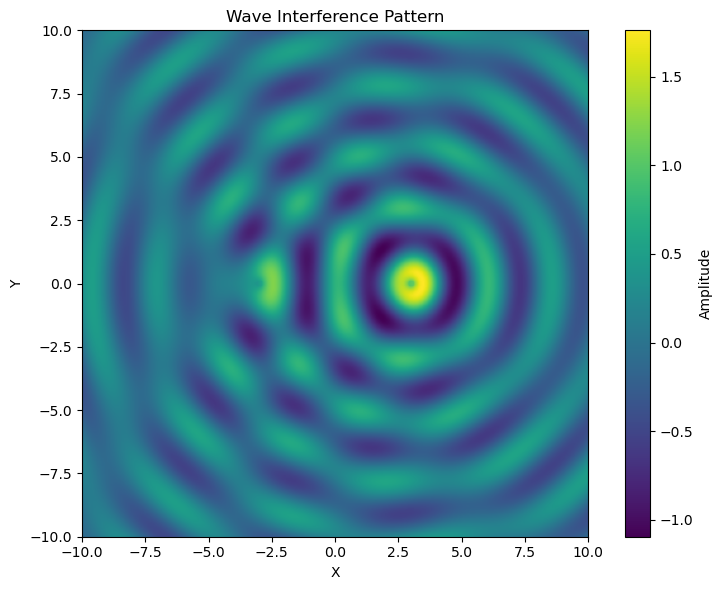

In [70]:
# Visualize the wave interference pattern
plot_wave(total_wave, "Wave Interference Pattern")

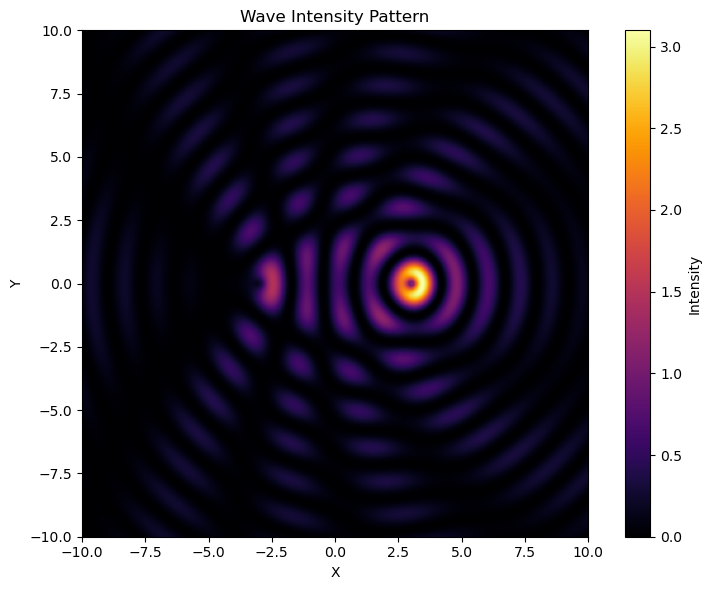

In [71]:
plot_intensity(total_wave)

Current Memory: 13.05 MB
Peak Memory: 36.99 MB


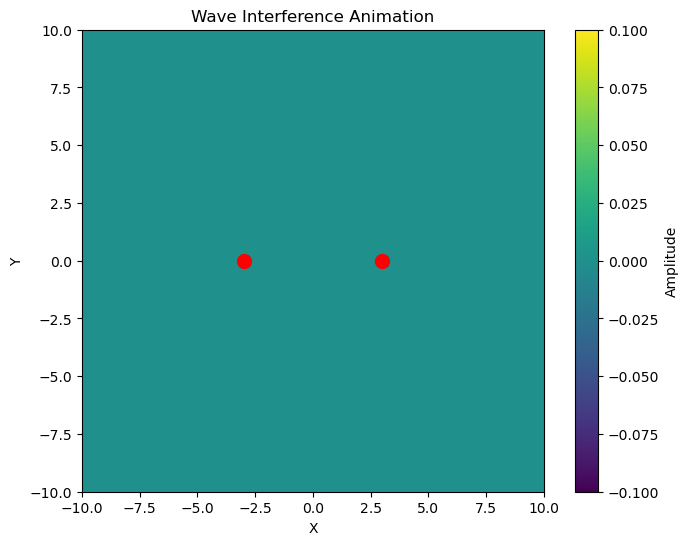

In [72]:
# Animate the wave interference pattern
animation = animate_interference(source1, source2, X, Y)

# Keep a reference to the animation and show the figure
stop_memory_tracking()
plt.show()